# NIRSpec Redshifted Emission Line

### Some NIRSpec Docs
- [Readout Patterns](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-instrumentation/nirspec-detectors/nirspec-detector-readout-modes-and-patterns#gsc.tab=0)
- [Recommended Strategies](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-observing-strategies/nirspec-detector-recommended-strategies#gsc.tab=0)

Total Exposure Time: 88900.71 s
Single Exposure Time: 8890.07 s
Single Integration Time: 1481.68 s
Integrated Line SNR: 30.06
Peak Line SNR: 5.59


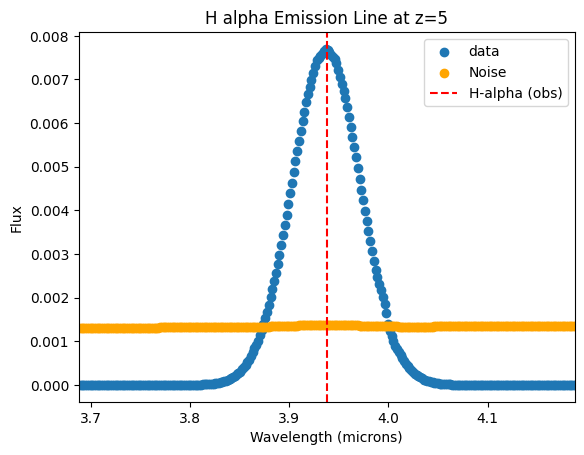

In [ ]:
# Pandeia reference data
import os
os.environ["pandeia_refdata"] = "../ref_data/pandeia/pandeia_data-2025.7-jwst"
os.environ["PYSYN_CDBS"] = "../ref_data/pandeia/trds"

# Exposure time calculator
from pandeia.engine.calc_utils import build_default_calc
from pandeia.engine.perform_calculation import perform_calculation

import matplotlib.pyplot as plt
import numpy as np

# Observing parameters
telescope = 'jwst'
instrument = 'nirspec'
mode = 'fixed_slit'
disperser = 'g395m'
filter = 'f290lp' 
readout_pattern = 'nrsirs2'

# Iteration parameters
ngroups = 190
nint = 6 
nexp = 10 
target_exp = 3600*24 # target exposure time in seconds

# Source parameters
offsets = {'x': 0., 'y': 0.}
geometry = 'point'
sed = 'flat'
sed_unit = 'fnu'
magnitude = 99

# Emission line parameters
name = 'H alpha'
emission_line_center = 0.6563 # H alpha, microns
emission_line_width = 1000 # km/s
emission_line_strength = 2e-18 # erg/s/cm2
redshift = 5
target_wavelength = emission_line_center * (1 + redshift)

# Exposure constraints
max_single_int = 1500 # max single integration time, seconds
max_single_exp = 10000 # max single exposure time, seconds

# Calculation
calc = build_default_calc(telescope, instrument, mode)

# Detector
calc['configuration']['instrument']['disperser'] = disperser
calc['configuration']['instrument']['filter'] = filter
calc['configuration']['detector']['readout_pattern'] = readout_pattern
calc['configuration']['detector']['nexp'] = nexp
calc['configuration']['detector']['ngroup'] = ngroups
calc['configuration']['detector']['nint'] = nint

# Background
calc['background_level'] = 'low'

# Spectrum
scene = calc['scene'][0]
scene['spectrum']['normalization'] = {}
scene['spectrum']['normalization']['type'] = 'jwst'
scene['spectrum']['normalization']['bandpass'] = 'nircam,lw_imaging,f444w'
scene['spectrum']['normalization']['norm_flux'] = magnitude
scene['spectrum']['normalization']['norm_fluxunit'] = 'abmag'
scene['shape']['geometry'] = 'point'
scene['spectrum']['name'] = name
scene['spectrum']['redshift'] = redshift
scene['spectrum']['sed'] = {'sed_type': sed, 'unit': sed_unit}

# Emission line
emission_line = {}
emission_line['id'] = 0
emission_line['name'] = name
emission_line['emission_or_absorption'] = 'emission'
emission_line['center'] = target_wavelength
emission_line['width'] = emission_line_width * (1 + redshift)
emission_line['strength'] = emission_line_strength
emission_line['profile'] = 'gaussian'
scene['spectrum']['lines'] = [emission_line]

# Result
report = perform_calculation(calc)
wave = report['1d']['extracted_flux'][0]
flux = report['1d']['extracted_flux'][1] 
noise = report['1d']['extracted_noise'][1]
sn_ext = report['1d']['sn'][1]

# Mask to isolate line
xmin = target_wavelength - 0.25
xmax = target_wavelength + 0.25
wave_mask = (wave >= xmin) & (wave <= xmax)
flux_mask = flux > noise
w = wave[wave_mask & flux_mask]
f = flux[wave_mask & flux_mask]
n = noise[wave_mask & flux_mask]

# Print exposure info
tot_exp = float(report['information']['exposure_specification']['total_exposure_time'])  # seconds
single_exp = float(report['information']['exposure_specification']['exposure_time'])  # seconds
single_int = single_exp / nint
print(f'Total Exposure Time: {tot_exp:.2f} s')
print(f'Single Exposure Time: {single_exp:.2f} s')
print(f'Single Integration Time: {single_int:.2f} s')

# Exposure constraints
if single_int > max_single_int:
    print(f'WARNING: Single integration time {single_int:.2f} s exceeds maximum of {max_single_int} s. Reduce ngroups')
if single_exp > max_single_exp:
    print(f'WARNING: Single exposure time {single_exp:.2f} s exceeds maximum of {max_single_exp} s. Reduce nint')
if tot_exp < target_exp:
    print(f'WARNING: Total exposure time {tot_exp:.2f} s is less than target of {target_exp} s. Increase nexp')

# Integrated line SNR
line_snr = np.sum(f) / np.sqrt(np.sum(n**2))
print(f'Integrated Line SNR: {line_snr:.2f}')

# Peak line SNR
if len(f) != 0:
    max_snr = np.argmax(f)
    max_noise = n[max_snr]
    print(f'Peak Line SNR: {f[max_snr]/max_noise:.2f}')
else:
    mf = np.argmax(flux)
    print(f'Peak Line SNR: {flux[mf]/noise[mf]:.2f} !!! flux below noise !!!')

# Plot
plt.title(f'{name} Emission Line at z={redshift}')
plt.scatter(wave, flux, label='data')
plt.scatter(wave, noise, color='orange', label='Noise')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Flux')
plt.axvline(target_wavelength, color='red', ls='--', label='H-alpha (obs)')
plt.xlim(xmin, xmax)
plt.legend()
plt.show()